In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied


In [3]:
epochs

Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.781 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,session_0,run_0
1,1,session_0,run_0
2,1,session_0,run_0
3,1,session_0,run_0
4,1,session_0,run_0
...,...,...,...
4195,1,session_0,run_0
4196,1,session_0,run_0
4197,1,session_0,run_0
4198,1,session_0,run_0


No projector specified for this dataset. Please consider the method self.add_proj.


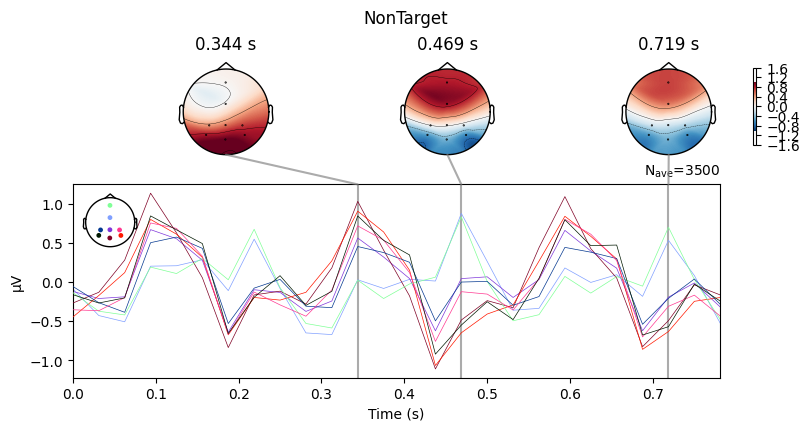

No projector specified for this dataset. Please consider the method self.add_proj.


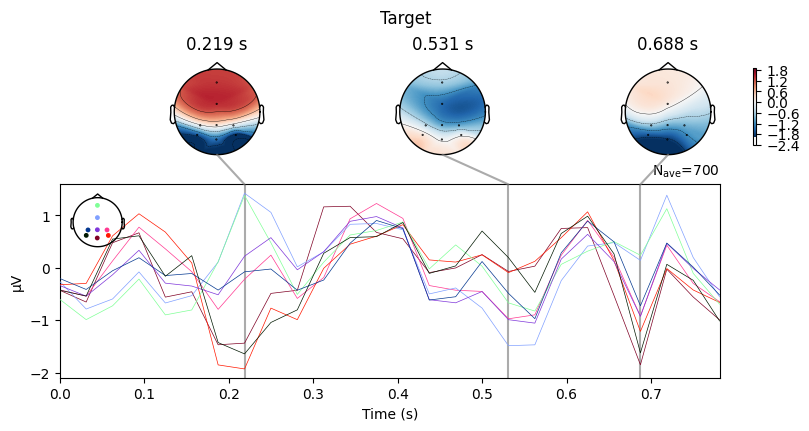

In [5]:
import numpy as np
ts_args=dict(ylim=dict(
    #eeg=[-40,40]
                      ))
joint_args=dict(ts_args=ts_args)
evokeds = []
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


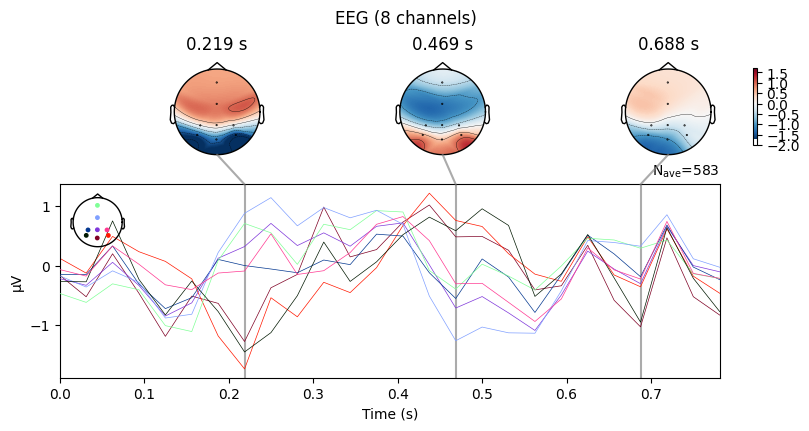

In [6]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
contrast.plot_joint(**joint_args);

In [7]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_12800/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(4200, 8, 26)

In [8]:
from hoda.hoda import HODA, f_multiway, aHODA
from hoda.gpu_opt import center
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import center, ledoit_wolf_shrinkage, combine_pvalues
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler


hoda = aHODA(
            rank=None,
            max_iter=256,
            tol=1e-8,
            init ='svd',
            shrinkage='lw',
            toeplitz=None,
            obj='rt',
            solver='lanczos',
            taper=False,
            keep_train_info=False,
            verbose=True,
            prune=False,
        )

%lprun -f HODA.fit hoda.fit(X,y)
hoda

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (1, 1) ...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (2, 2) ...
Initializing factors...
Fitting discriminative Tucker model...


...

Fitted Tucker model of rank (4, 4) ...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (3, 3) ...


aHODA()

Timer unit: 1e-09 s

Total time: 16.32 s
File: /project/src/hoda/hoda.py
Function: fit at line 300

Line #      Hits         Time  Per Hit   % Time  Line Contents
   300                                               def fit(self, X, y):
   301                                                   # Setup
   302                                                   # X = tl.tensor(X.copy(), dtype=X.dtype)
   303         5  142060587.0    3e+07      0.9          X = tl.tensor(X, dtype=X.dtype)
   304         5   15209659.0    3e+06      0.1          self.classes_, class_counts = np.unique(y, return_counts=True)
   305         5    5252497.0    1e+06      0.0          class_counts = tl.tensor(class_counts)
   306         5      28256.0   5651.2      0.0          n_samples, *shape = X.shape
   307         5      20044.0   4008.8      0.0          self.shape_ = shape
   308         5      10099.0   2019.8      0.0          order = len(shape)
   309                                           
   310 

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

if hoda.keep_train_info:
    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_tr', ax=axs[0])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_rt', ax=axs[1])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='mse', ax=axs[2])
    axs[2].set(yscale="log")
    axs[2].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='update', ax=axs[3])
    axs[3].set(yscale="log")


    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='objective',hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='rank',hue='mode', ax=axs[1])
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='update',hue='mode', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='shrinkage',hue='mode', ax=axs[3])


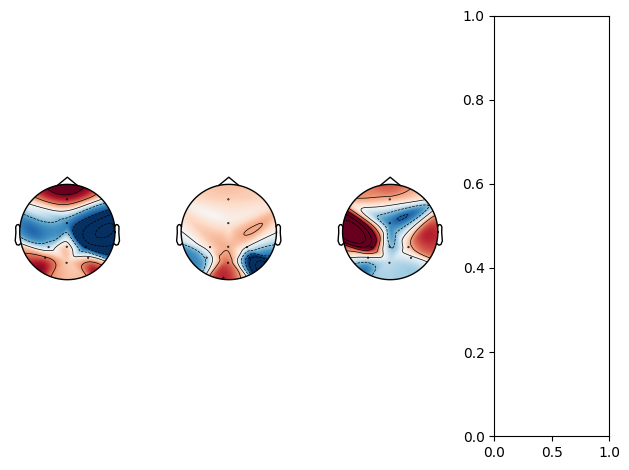

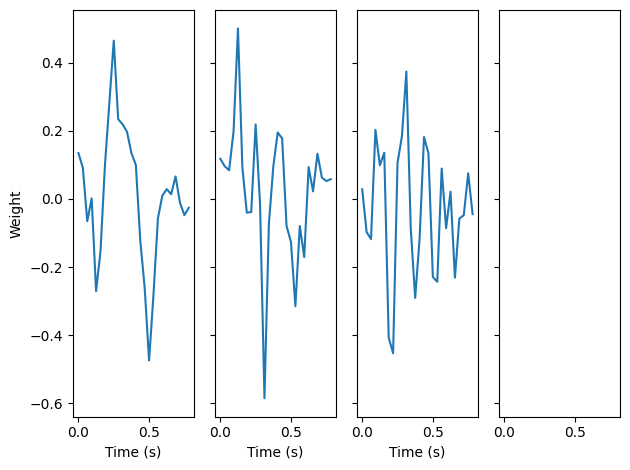

In [13]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl


col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_(0)):
    w = tl.to_numpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(1)):
    w = tl.to_numpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


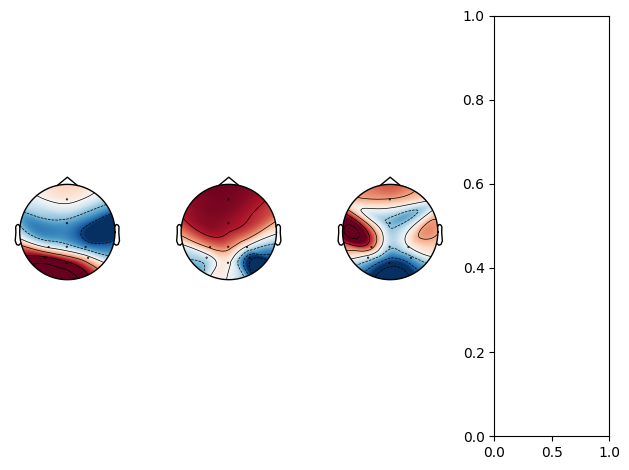

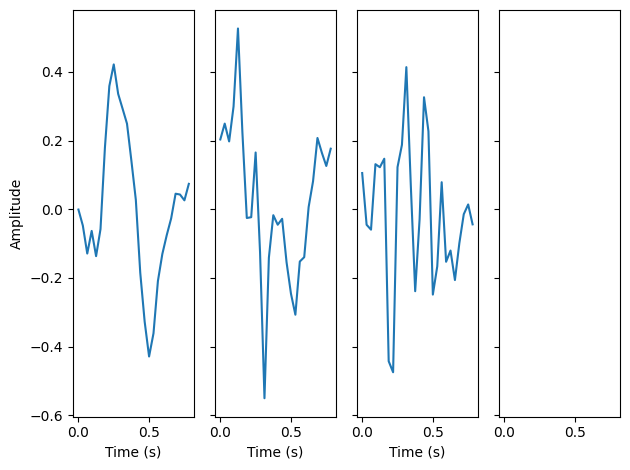

In [15]:
n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_(0)):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude');


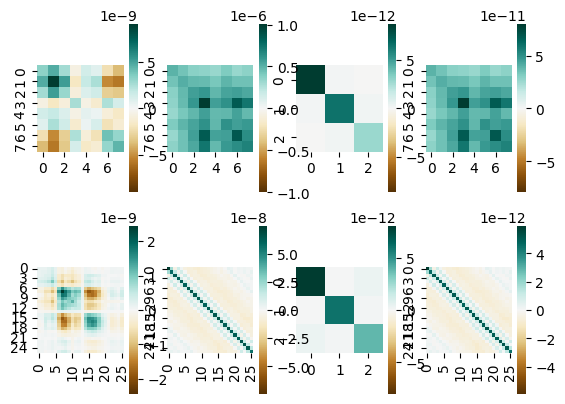

In [16]:
_, axs = plt.subplots(2,4,)
for k in range(2):
    
    scatter_b = tl.to_numpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = tl.to_numpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= tl.to_numpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov =  tl.to_numpy(hoda.cov_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

In [17]:
Xt = hoda.transform(X)

[[4.18549037e-038 1.53314989e-025 1.05974583e-003]
 [1.94474362e-101 1.98653314e-017 4.21222356e-029]
 [9.97346411e-029 9.58712699e-002 4.98820907e-035]]

[2.08411401e-38 1.58085407e-06 6.37128985e-34]

[9.74173140e-01 2.45625268e-31 6.30706534e-19]


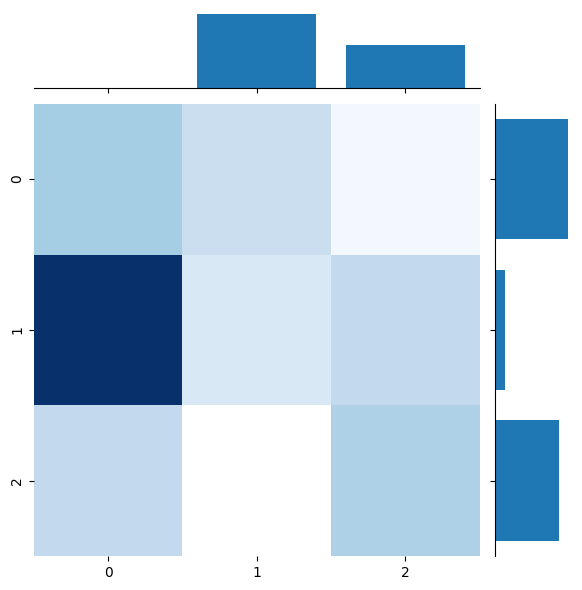

In [18]:
from hoda.hoda import f_multiway
from hoda.gpu_opt import combine_pvalues

F, p = f_oneway(Xt,y)

classes = np.unique(y)
y_like_Xt = tl.zeros_like(Xt)
for ci, c in enumerate(classes):
    y_like_Xt[y==c] = ci


F_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])
F_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])


F_sp = tl.to_numpy(F_sp)
F_tmp = tl.to_numpy(F_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)

g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05/p.size,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)

print(p)
print()
print(p_sp)
print()
print(p_tmp)

In [19]:
from sklearn.feature_selection import SelectFwe

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))
Xt_flat.shape

(4200, 9)

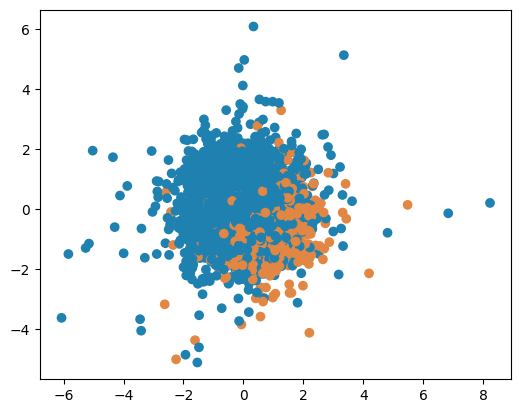

In [20]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt_flat.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_flat))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_12800/2414566788.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))


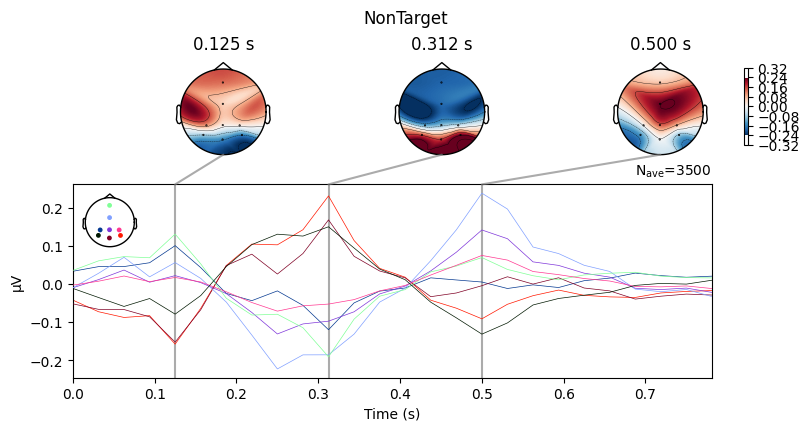

No projector specified for this dataset. Please consider the method self.add_proj.


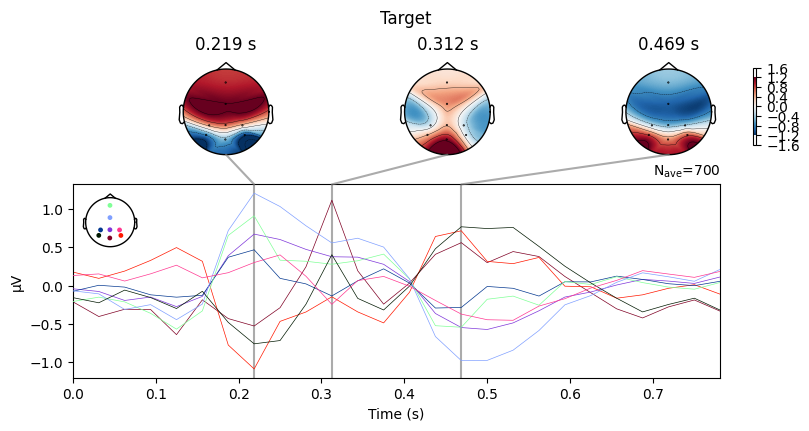

In [21]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls, **joint_args)
    else:
        evoked_rec.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


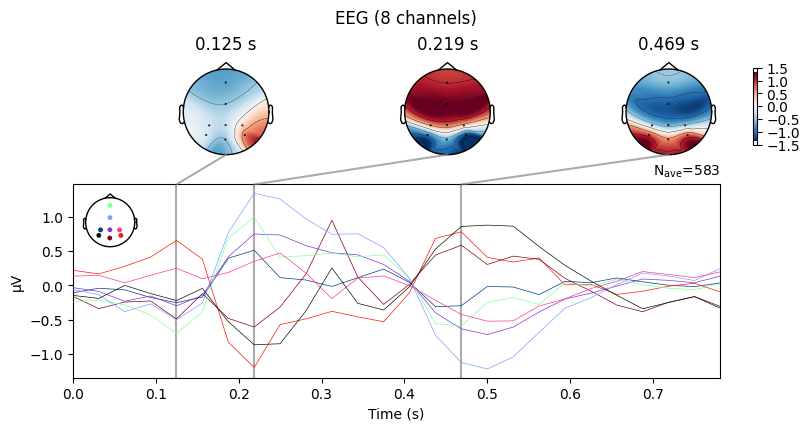

In [22]:
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
contrast_rec.plot_joint(**joint_args);